# Deep Operator Networks (DeepONets) in PhysicsNeMo

Let us start by recalling the Universal Approximation theorem for _functionals_ [1]:

<span style="display:block;text-align:center">![deeponet_thm](./img/deeponet_thm.png)</span>

Which, in turns, allows for the definition of an NN architecture, by identifying the _trunk_ and _branch_ part as neural networks [2]:
$$
\begin{split}
        G_\theta [u](y)&\equiv \sum_{k=1}^{N} 
    \underbrace{{
        \sum_{i=1}^{M} c_i^k\, g\!\left( \sum_{j=1}^{m} \xi_{ij}^k\, u(x_j) + b_i^k \right)
    } }_{\text{branch}}
    \ \  
    \underbrace{{
        g(\omega_k\cdot y + \zeta_k)
    } }_{\text{trunk}} \\ 
    &\equiv \sum_{k=1}^N {
         \sum_{i=1}^{M} c_i^k\, g\!\left( \sum_{j=1}^{m} \text{branchnet}_{ij}^k(u(x_j)) \right)
        } \cdot {
            \text{trunknet} (\omega_k, \zeta_k  ; y)\,
    }
\end{split}
$$

Visually:

<span style="display:block;text-align:center">![deeponet_arch](./img/deeponet_arch.png)</span>


----------------------------

**References:**

[1] Tianping Chen and Hong Chen, "Universal approximation to nonlinear operators by neural networks with arbitrary activation functions and its application to dynamical systems," in IEEE Transactions on Neural Networks,  July 1995, doi: 10.1109/72.392253. pdf

[2] Lu, L., Jin, P., Pang, G. et al. Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. Nat Mach Intell 3, 218–229 (2021) DOI 10.1038/s42256-021-00302-5


In [1]:
from physicsnemo.sym.hydra import to_yaml
from physicsnemo.sym.hydra.utils import compose
# must be passed to ensure no bug arises 
# https://github.com/NVIDIA/physicsnemo-sym/issues/206
from physicsnemo.sym.hydra.utils import register_amp_configs
register_amp_configs()  

cfg = compose(config_path="./conf/", config_name="config_DeepO")
cfg.network_dir = "notebook_deeponet_outputs"  # Set the network directory for checkpoints

print(to_yaml(cfg))

/usr/local/lib/python3.12/dist-packages/physicsnemo/sym/hydra/utils.py:156: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(
TorchScript default is being turned off due to PyTorch version mismatch.


training:
  max_steps: 100000
  grad_agg_freq: 1
  rec_results_freq: 1000
  rec_validation_freq: 1000
  rec_inference_freq: ${training.rec_results_freq}
  rec_monitor_freq: ${training.rec_results_freq}
  rec_constraint_freq: ${training.rec_results_freq}
  save_network_freq: 1000
  print_stats_freq: 100
  summary_freq: 1000
  grad_clip_max_norm: 0.5
  monitor_grad_clip: true
  ntk:
    use_ntk: false
    save_name: null
    run_freq: 1000
amp:
  enabled: false
  mode: per_order_scaler
  dtype: float16
  autocast_activation: false
  autocast_firstlayer: false
  default_max_scale_log2: 0
  custom_max_scales_log2: {}
graph:
  func_arch: false
  func_arch_allow_partial_hessian: true
stop_criterion:
  metric: null
  min_delta: null
  patience: 50000
  mode: min
  freq: 1000
  strict: false
profiler:
  profile: false
  start_step: 0
  end_step: 100
  name: nvtx
network_dir: notebook_deeponet_outputs
initialization_network_dir: ''
save_filetypes: np
summary_histograms: 'off'
jit: true
jit_use_

In [9]:
print(f"""Trunk Architecture:

{to_yaml(cfg.arch.trunk)}
----------------------------

Branch Architecture:

{to_yaml(cfg.arch.branch)}
----------------------------
""")

Trunk Architecture:

arch_type: fourier
input_keys:
- x
- 'y'
output_keys:
- trunk
- 256
detach_keys: ???
scaling: null
frequencies: ('axis', [0, 1, 2, 3, 4])
frequencies_params: ('axis', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
activation_fn: silu
layer_size: 128
nr_layers: 4
skip_connections: false
weight_norm: true
adaptive_activations: false

----------------------------

Branch Architecture:

arch_type: pix2pix
input_keys:
- coeff
output_keys:
- branch
detach_keys: ???
scaling: null
dimension: 2
conv_layer_size: 32
n_downsampling: 3
n_blocks: 3
scaling_factor: 1
batch_norm: true
padding_type: reflect
activation_fn: relu

----------------------------



# 1. Define keys and load data

We use an useful handle to load the data; in `utils` we find the `utilities.py` containing a set of useful functions to download, store, and load the data for each task we need (thanks NVIDIA);

In particular, the data are stored on a google drive folder (!), as can be seem # lines 31-45:
```python
# list of FNO dataset url ids on drive: https://drive.google.com/drive/folders/1UnbQh2WWc6knEHbLn-ZaXrKUZhp7pjt-
_FNO_datatsets_ids = {
    "Darcy_241": "1ViDqN7nc_VCnMackiXv_d7CHZANAFKzV",
    "Darcy_421": "1Z1uxG9R8AdAGJprG5STcphysjm56_0Jf",
}
_FNO_dataset_names = {
    "Darcy_241": (
        "piececonst_r241_N1024_smooth1.hdf5",
        "piececonst_r241_N1024_smooth2.hdf5",
    ),
    "Darcy_421": (
        "piececonst_r421_N1024_smooth1.hdf5",
        "piececonst_r421_N1024_smooth2.hdf5",
    ),
}
```
So, [here](https://drive.google.com/drive/folders/1UnbQh2WWc6knEHbLn-ZaXrKUZhp7pjt-) there is the repo containing all the relevant open source data offered by NVIDIA for their PDE tutorials. 


Notice that the relevant method here, `load_deeponet_dataset`, loads the data _and_ define the $(x,y)$ inputs for the _trunk_ model:

```python
def load_deeponet_dataset(
    path, input_keys, output_keys, n_examples=None, filter_size=8
):
    "Loads a deeponet dataset"
    # load dataset
    invar, outvar = load_FNO_dataset(path, input_keys, output_keys, n_examples)
    # reduce shape needed for deeponet
    for key, value in invar.items():
        invar[key] = value[:, :, ::filter_size, ::filter_size]
    for key, value in outvar.items():
        outvar[key] = value[:, :, ::filter_size, ::filter_size]
    res = next(iter(invar.values())).shape[-1]
    nr_points_per_sample = res**2
    # tile invar
    tiled_invar = {
        key: np.concatenate(
            [
                np.tile(value[i], (nr_points_per_sample, 1, 1, 1))
                for i in range(n_examples)
            ]
        )
        for key, value in invar.items()
    }
    # tile outvar
    tiled_outvar = {key: value.flatten()[:, None] for key, value in outvar.items()}
    # add cord points
    x = np.linspace(0.0, 1.0, res)
    y = np.linspace(0.0, 1.0, res)
    x, y = [a.flatten()[:, None] for a in np.meshgrid(x, y)]
    tiled_invar["x"] = np.concatenate(n_examples * [x], axis=0)
    tiled_invar["y"] = np.concatenate(n_examples * [y], axis=0)
    return (tiled_invar, tiled_outvar)
```


In [13]:
from utils.utilities import download_FNO_dataset, load_deeponet_dataset
from physicsnemo.sym.key import Key

branch_input_keys = [Key("coeff")]
trunk_input_keys  = [Key("x"), Key("y")]
output_keys = [Key("sol")]

download_FNO_dataset("Darcy_241", outdir="datasets/")
invar_train, outvar_train = load_deeponet_dataset(
    "datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5",
    [k.name for k in branch_input_keys],
    [k.name for k in output_keys],
    n_examples=1000,
)
invar_test, outvar_test = load_deeponet_dataset(
        "datasets/Darcy_241/piececonst_r241_N1024_smooth2.hdf5",
    [k.name for k in branch_input_keys],
    [k.name for k in output_keys],
    n_examples=10,
)

loaded: /home/private/PINN2026/5. Darcy Flow with Neural Operators/datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5
avaliable keys: ['Kcoeff', 'Kcoeff_x', 'Kcoeff_y', 'coeff', 'sol']
selected key: coeff, mean: 7.48360e+00, std: 4.49996e+00
selected key: sol, mean: 5.74634e-03, std: 3.88433e-03
loaded: /home/private/PINN2026/5. Darcy Flow with Neural Operators/datasets/Darcy_241/piececonst_r241_N1024_smooth2.hdf5
avaliable keys: ['Kcoeff', 'Kcoeff_x', 'Kcoeff_y', 'coeff', 'sol']
selected key: coeff, mean: 7.67474e+00, std: 4.49661e+00
selected key: sol, mean: 5.64061e-03, std: 3.81635e-03


### 1.1. Explore data

In [20]:
print(f"Invar  keys: {invar_train.keys()};\tcoeff shape:\t{invar_train['coeff'].shape}")
print(f"Outvar keys: {outvar_train.keys()};\t\tsol shape:\t{outvar_train['sol'].shape}")

Invar  keys: dict_keys(['coeff', 'x', 'y']);	coeff shape:	(961000, 1, 31, 31)
Outvar keys: dict_keys(['sol']);		sol shape:	(961000, 1)


In [26]:
print(f"Please notice the indexing: {invar_train['coeff'].shape[0]} = {invar_train['coeff'].shape[-1]*invar_train['coeff'].shape[-2]}*1000;\n\t\tN_sim = 1_000")

Please notice the indexing: 961000 = 961*1000;
		N_sim = 1_000


In [29]:
def retrieve_sim(
    sim_idx: int, 
    data  : dict = {**invar_train, **outvar_train},
    N_sim : int = 1_000
):
    N_batch_sims = 31*31
    while sim_idx >= N_sim:
        sim_idx -= N_sim
    #print(sim_idx * N_batch_sims)
    coeff = data['coeff'][sim_idx * N_batch_sims, 0, :, :]
    x = data['x'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    y = data['y'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    true_sol = data['sol'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    return coeff, x[:, 0], y[:, 0], true_sol[:, 0]

In [32]:
coeff, x, y, true_sol = retrieve_sim(sim_idx=7)

In [42]:
import matplotlib.pyplot as plt

def show_by_idx(
    sim_idx: int, 
    data  : dict = {**invar_train, **outvar_train},
    N_sim : int = 1_000 ,
    cmap: str = 'viridis'
):
    coeff, x, y, true_sol = retrieve_sim(sim_idx, data=data, N_sim=N_sim)

    _kwargs = {
        'cmap': cmap, 
        'origin': "lower",
        "aspect": "equal",
        "extent": [
            x.min(), x.max(), 
            y.min(), y.max()
        ]
    }
    
    fig, axs = plt.subplots(1,2,dpi=300, figsize=(8,4) )
    fig.suptitle(f"Sim idx {sim_idx}")
    axs[0].imshow(coeff, **_kwargs)
    axs[0].set_title(f"$a(x,y)$")
    
    axs[1].imshow(true_sol.reshape(31,31), **_kwargs)
    axs[1].set_title(f"$u(x,y)$")
    return fig 


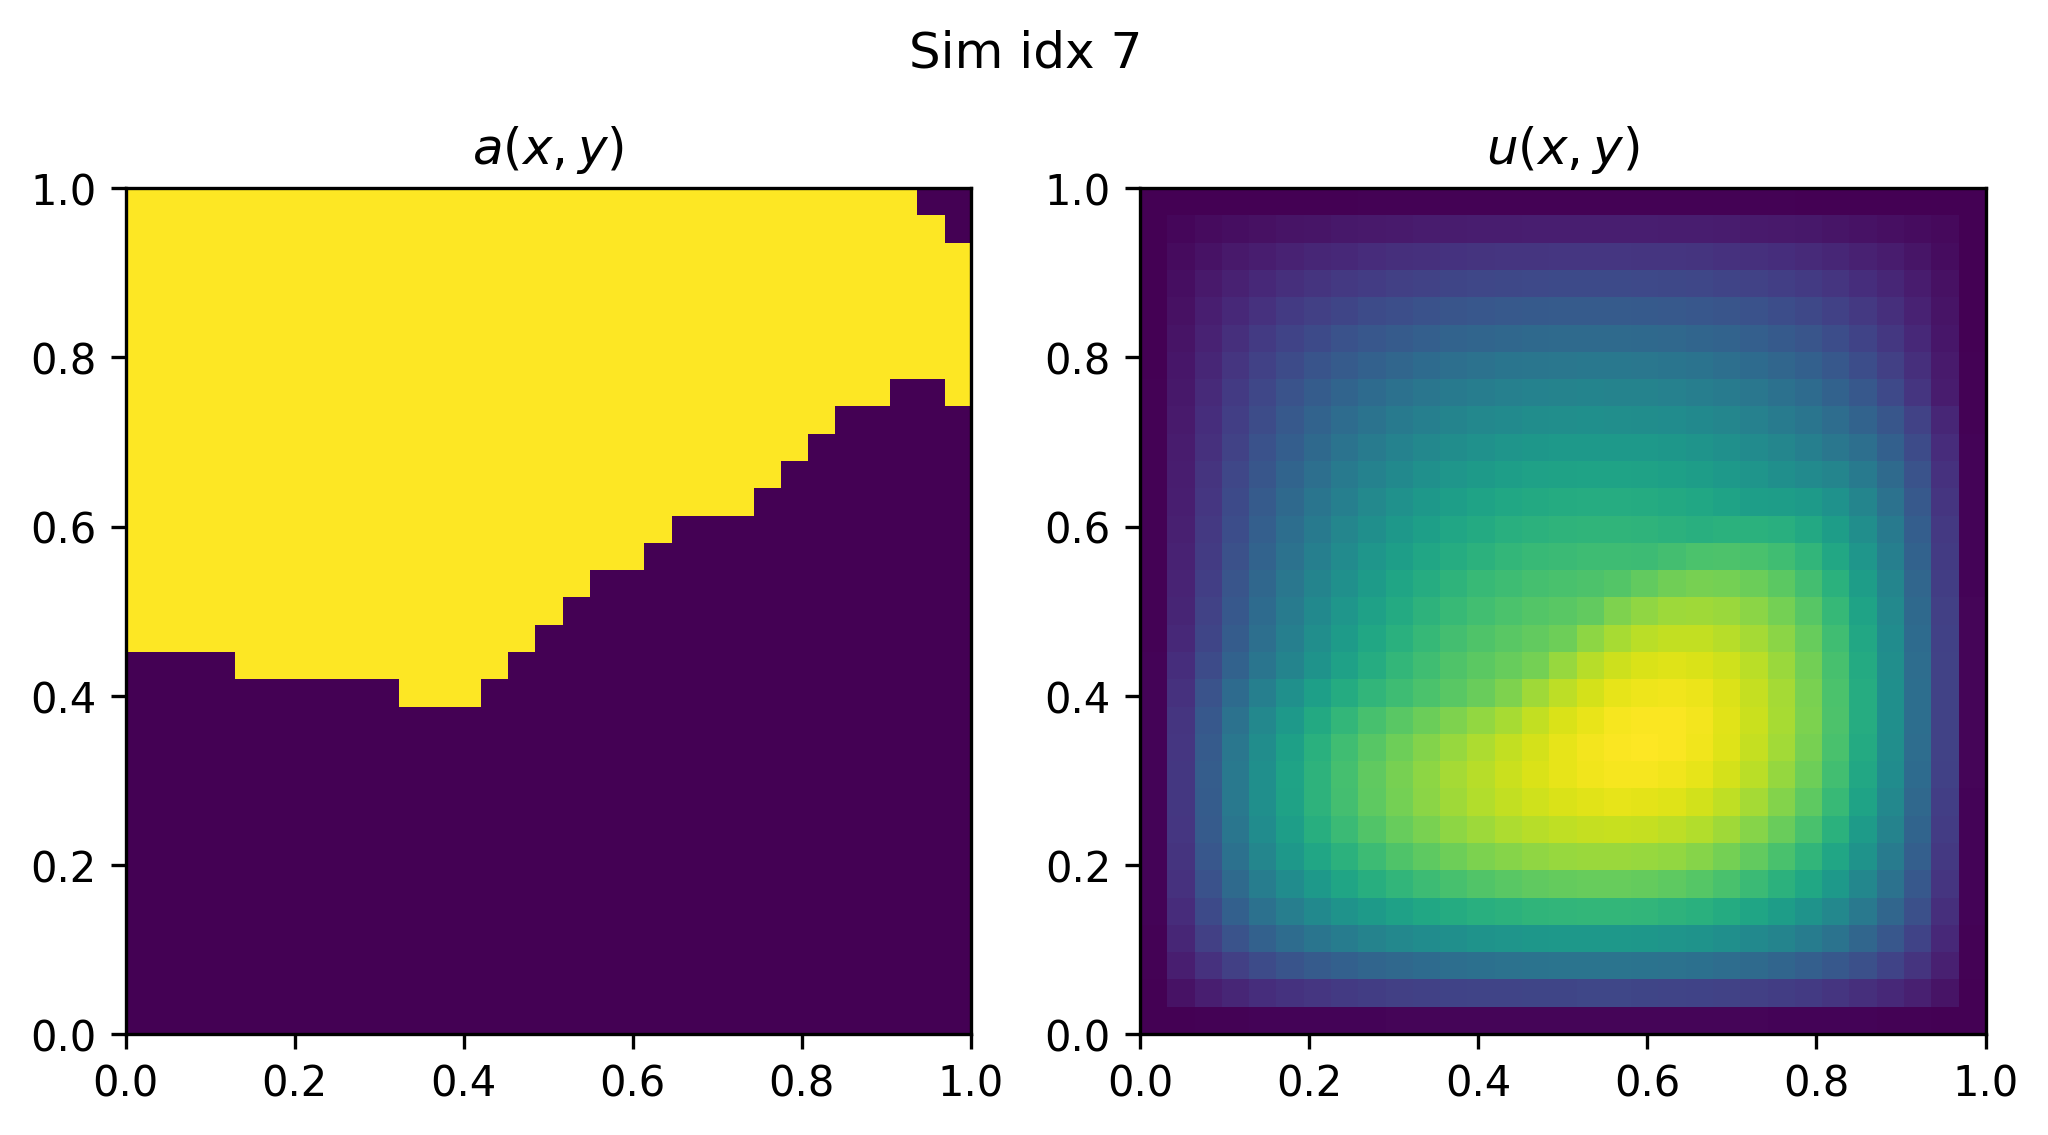

In [43]:
fig = show_by_idx(7)
fig.show()

## 2. Initialise the Model & make nodes

In [44]:
from physicsnemo.sym.hydra import instantiate_arch

# Models
branch_net = instantiate_arch(
    cfg=cfg.arch.branch,
)
trunk_net = instantiate_arch(
    cfg=cfg.arch.trunk,
)
deeponet = instantiate_arch(
    cfg=cfg.arch.deeponet,
    branch_net = branch_net,
    trunk_net  = trunk_net,
)

# Nodes
nodes = [deeponet.make_node(name="deepo")]

The combination of branch_net (<class 'physicsnemo.sym.models.pix2pix.Pix2PixArch'>) and trunk_net(<class 'physicsnemo.sym.models.fourier_net.FourierNetArch'>) does not support FuncArch.


In [54]:
print(f"Branch Net Torch implementation:\n")
display(branch_net)
print(f"\nIt is easy to see that is an UNet, like in the original Pix2Pix paper by Isola et al, 2017.")
print(f"-----------------------------------")

print(f"Trunk Net Torch implementation:\n")
display(trunk_net)
print(f"\nThis, instead, is a standard FourierNet to embed the $(x,y)$ coordinates")
print(f"-----------------------------------")

print(f"\n\n\nIn one shot, the DeepONet architecture we selected:\n")
display(deeponet)

Branch Net Torch implementation:



Pix2PixArch(
  (_impl): Pix2Pix(
    (model): Sequential(
      (0): ReflectionPad2d((3, 3, 3, 3))
      (1): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1))
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): RecursiveScriptModule(original_name=ReLU)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): RecursiveScriptModule(original_name=ReLU)
      (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): RecursiveScriptModule(original_name=ReLU)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (12): RecursiveScriptModule(original_name=ReLU)
      (13): ResnetBlock(
 


It is easy to see that is an UNet, like in the original Pix2Pix paper by Isola et al, 2017.
-----------------------------------
Trunk Net Torch implementation:



FourierNetArch(
  (fourier_layer_xyzt): FourierLayer()
  (fc): FullyConnectedArchCore(
    (layers): ModuleList(
      (0): FCLayer(
        (linear): WeightNormLinear(in_features=22, out_features=128, bias=True)
      )
      (1-3): 3 x FCLayer(
        (linear): WeightNormLinear(in_features=128, out_features=128, bias=True)
      )
    )
    (final_layer): FCLayer(
      (activation_fn): Identity()
      (linear): Linear(in_features=128, out_features=256, bias=True)
    )
  )
)


This, instead, is a standard FourierNet to embed the $(x,y)$ coordinates
-----------------------------------



In one shot, the DeepONet architecture we selected:



DeepONetArch(
  (branch_net): Pix2PixArch(
    (_impl): Pix2Pix(
      (model): Sequential(
        (0): ReflectionPad2d((3, 3, 3, 3))
        (1): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1))
        (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): RecursiveScriptModule(original_name=ReLU)
        (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): RecursiveScriptModule(original_name=ReLU)
        (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (9): RecursiveScriptModule(original_name=ReLU)
        (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (12): Recursiv

## 3. Domain & data constraint

### 3.1. Domain and Train

We need to call the `DeepONetConstraint` physicsnemo class to define its data constraint

In [56]:
from physicsnemo.sym.domain import Domain
from physicsnemo.sym.domain.constraint.continuous import DeepONetConstraint

# make domain
domain = Domain()

# add constraint to domain
data = DeepONetConstraint.from_numpy(
    nodes  = nodes,
    invar  = invar_train,
    outvar = outvar_train,
    batch_size = cfg.batch_size.train,
)
domain.add_constraint(data, "data")

### 3.2. Validator

In [57]:
from physicsnemo.sym.domain.validator import PointwiseValidator

# add validators
val = PointwiseValidator(
    nodes=nodes,
    invar=invar_test,
    true_outvar=outvar_test,
    plotter=None,
)
domain.add_validator(val, "val")

## 4. Solve

In [59]:
from physicsnemo.sym.solver import Solver

# make solver
slv = Solver(cfg, domain)

# start solver
slv.solve()

/usr/local/lib/python3.12/dist-packages/physicsnemo/sym/amp.py:221: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  super().__init__(*args, **kwargs)


## 5. Visualise Inference & Validation

### 5.1. Load validation data

In [60]:
import numpy as np
data = np.load("./notebook_deeponet_outputs/validators/val.npz", allow_pickle=True)["arr_0"].item()

In [61]:
def retrieve_val_sim(
    sim_idx: int, 
    data: np.array, 
    N_sim: int = 9, 
):
    N_batch_sims = 31*31
    while sim_idx >= N_sim:
        sim_idx -= N_sim
    # unpack data
    coeff = data['coeff']
    x = data['x']
    y = data['y']
    true_sol = data['true_sol']
    pred_sol = data['pred_sol']
    #print(sim_idx * N_batch_sims)
    coeff = data['coeff'][sim_idx * N_batch_sims, 0, :, :]
    x = data['x'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    y = data['y'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    true_sol = data['true_sol'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    pred_sol = data['pred_sol'][sim_idx * N_batch_sims: (sim_idx+1) * N_batch_sims]
    return coeff, x[:, 0], y[:, 0], true_sol[:, 0], pred_sol[:, 0]


### 5.2. Inference plot

In [62]:
def inference_by_idx(sim_idx: int, data: np.array, N_sim: int = 9,  cmap: str = 'viridis'):
    coeff, x, y, true_sol, pred_sol = retrieve_val_sim(sim_idx=sim_idx, data=data, N_sim=N_sim)

    _kwargs = {
        'cmap': cmap, 
        'origin': "lower",
        "aspect": "equal",
        "extent": [
            x.min(), x.max(), 
            y.min(), y.max()
        ]
    }
    
    fig, axs = plt.subplots(1,2,dpi=300, figsize=(8,4) )
    fig.suptitle(f"Sim idx {sim_idx}")
    axs[0].imshow(coeff)
    axs[0].set_title(f"$a(x,y)$")
    
    axs[1].imshow(true_sol.reshape(31,31))
    axs[1].set_title(f"$u(x,y)$")
    return fig 


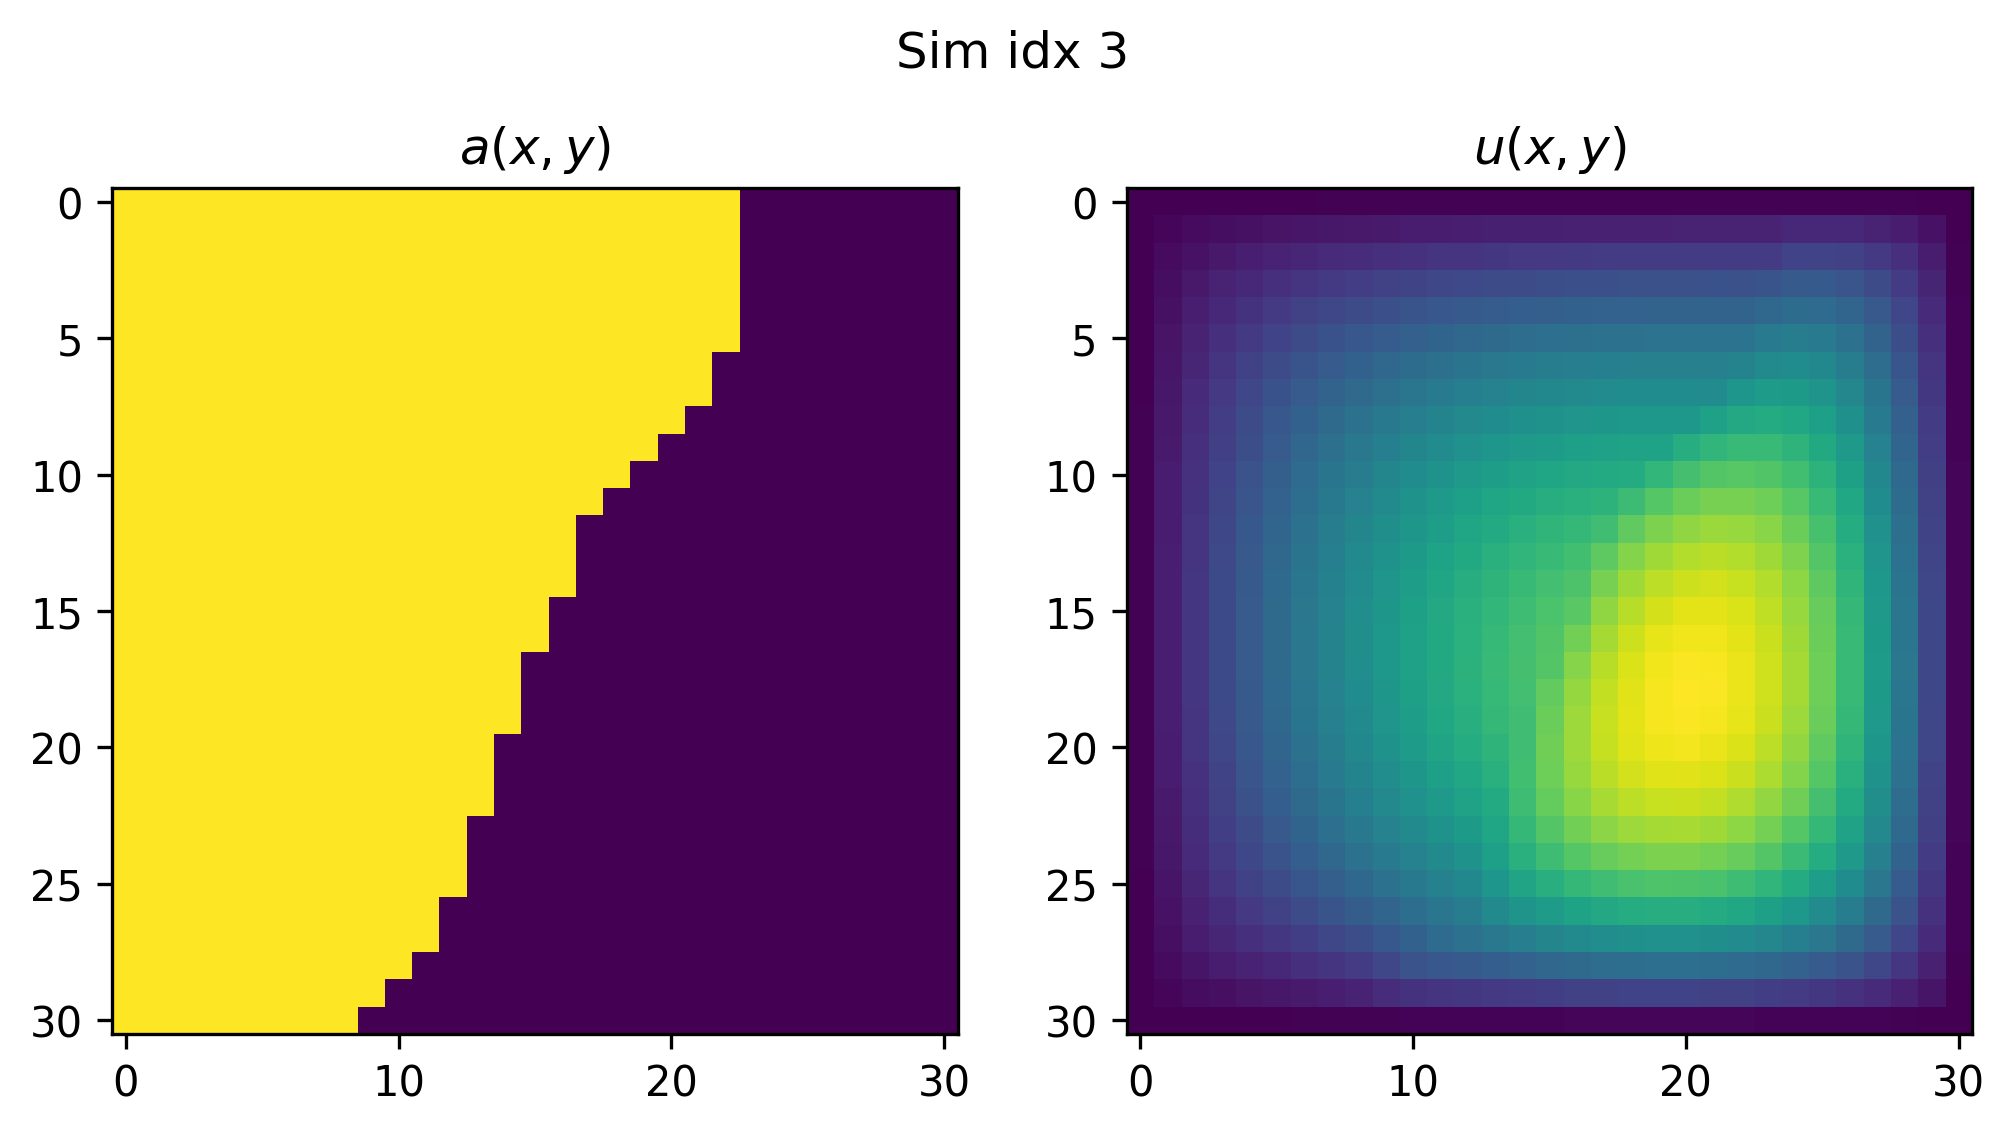

In [63]:
fig = inference_by_idx(sim_idx = 3, data = data)
fig.show()

### 5.3. Validation Plot

In [66]:
def validation_by_idx(sim_idx: int, data: np.array, N_sim: int = 9,  cmap: str = 'viridis'):
    coeff, x, y, true_sol, pred_sol = retrieve_val_sim(sim_idx=sim_idx, data=data, N_sim=N_sim)
    
    _kwargs = {
        'cmap': cmap, 
        'origin': "lower",
        "aspect": "equal",
        "extent": [
            x.min(), x.max(), 
            y.min(), y.max()
        ]
    }
    
    fig, axs = plt.subplots(1,4,dpi=300, figsize=(16,4) )
    fig.suptitle(f"Sim idx {sim_idx}")
    axs[0].imshow(coeff, **_kwargs)
    axs[0].set_title(f"Coeff")
    
    axs[1].imshow(pred_sol.reshape(31,31), **_kwargs)
    axs[1].set_title(f"pred_sol")
    
    axs[2].imshow(true_sol.reshape(31,31), **_kwargs)
    axs[2].set_title(f"true_sol")
    
    axs[3].imshow(
        (
            np.abs(true_sol - pred_sol) 
        ).reshape(31,31),
        vmin=true_sol.min(), 
        vmax=true_sol.max(),
        **_kwargs
    )
    axs[3].set_title(f"Rel. ERR.")
    return fig

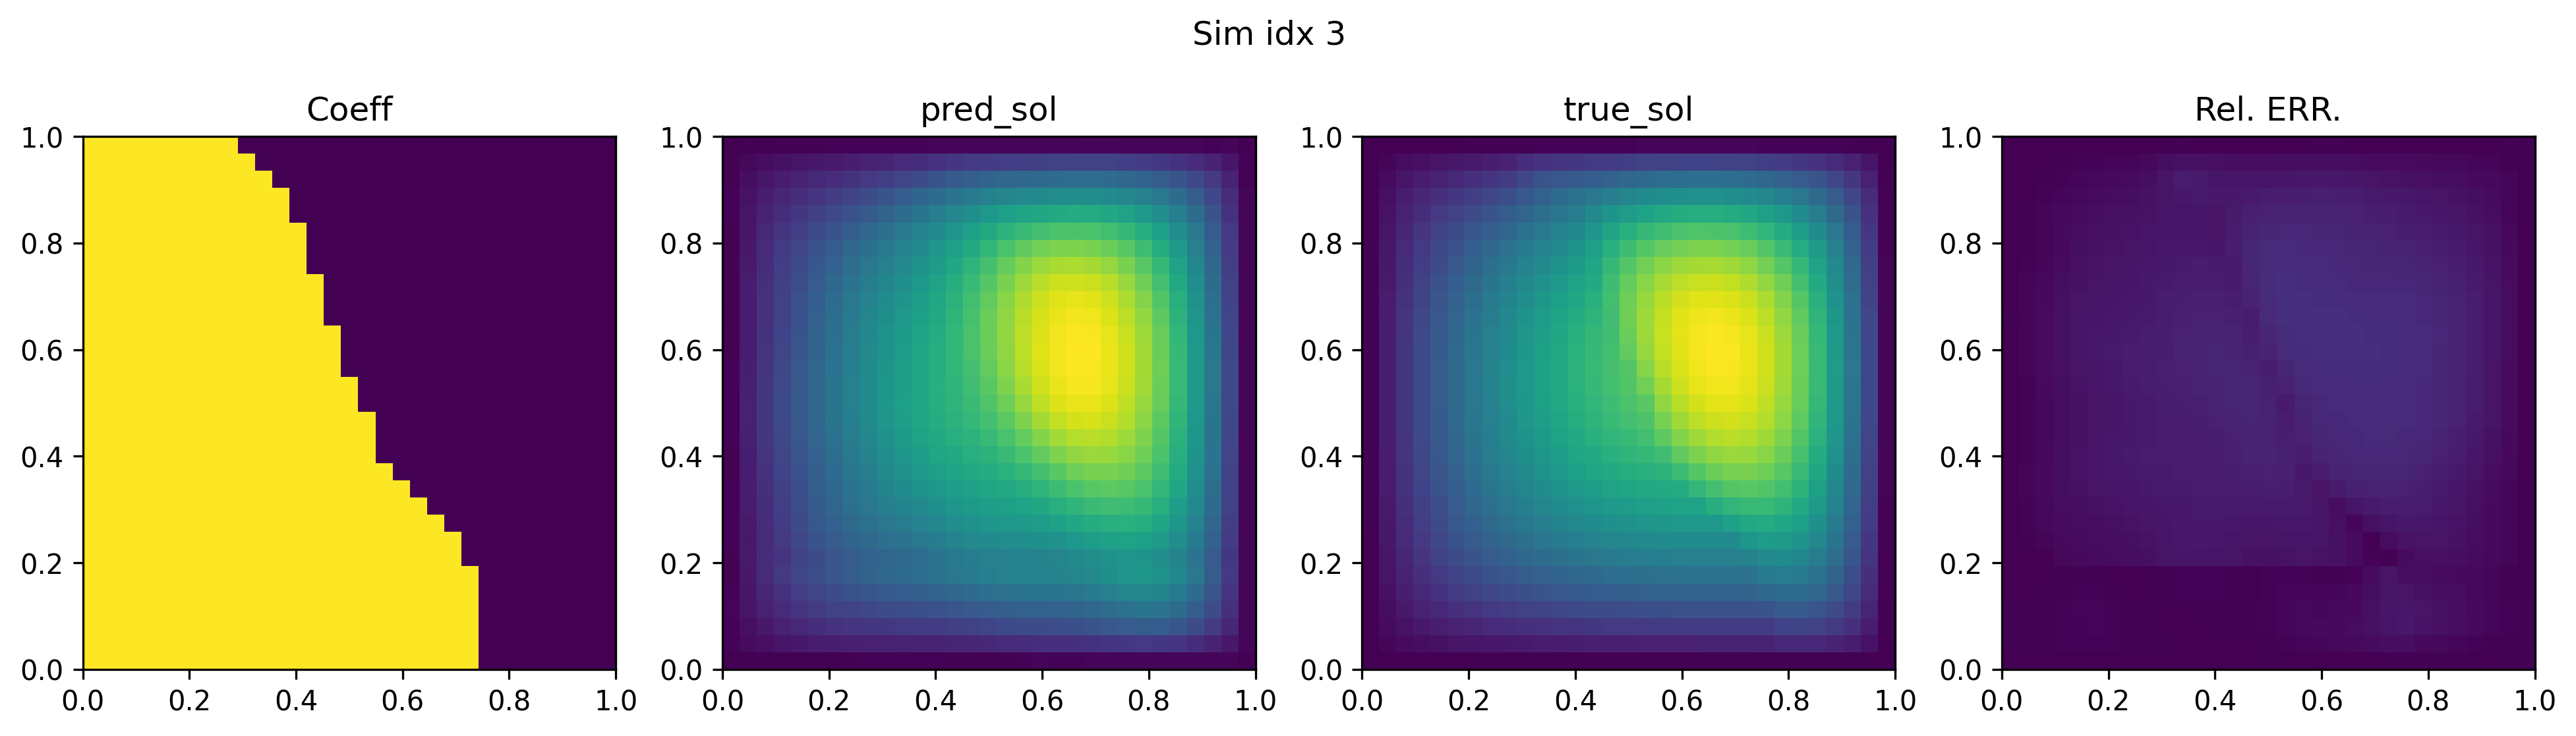

In [67]:
fig = validation_by_idx(sim_idx = 3, data = data)
fig.show()